<a href="https://colab.research.google.com/github/Nehasatheesh04/Image_and_video_processing_Lab/blob/main/DIP_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LAB CYCLE 1


In [ ]:

!pip install opencv-python-headless matplotlib


In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os


Q1

In [ ]:
# Upload an image
uploaded = files.upload()

# Get filename
image_filename = list(uploaded.keys())[0]
print(f"\nUploaded File: {image_filename}")


In [ ]:
#a: Read the image
image = cv2.imread(image_filename)

# Convert from BGR (OpenCV default) to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show the image
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()


In [ ]:
#b: Get image information
height, width, channels = image.shape
image_size = os.path.getsize(image_filename)

print("Image Information:")
print(f"Dimensions     : {width} x {height}")
print(f"Channels       : {channels}")
print(f"File Size      : {image_size / 1024:.2f} KB")


In [ ]:
# c: Save compressed copy (JPEG) and find compression ratio
compressed_filename = "compressed_image.jpg"
cv2.imwrite(compressed_filename, image, [int(cv2.IMWRITE_JPEG_QUALITY), 50])  # 50% quality

compressed_size = os.path.getsize(compressed_filename)

compression_ratio = image_size / compressed_size
print(f"Compressed Size: {compressed_size / 1024:.2f} KB")
print(f"Compression Ratio (Original/Compressed): {compression_ratio:.2f}")


In [ ]:
# Step 4d: Display negative of the image
negative_image = 255 - image
negative_rgb = cv2.cvtColor(negative_image, cv2.COLOR_BGR2RGB)

plt.imshow(negative_rgb)
plt.title("Negative Image")
plt.axis("off")
plt.show()


Q2


In [ ]:
# Load image in grayscale
gray_image = cv2.imread(image_filename, cv2.IMREAD_GRAYSCALE)

# Plot grayscale histogram
plt.figure(figsize=(8, 5))
plt.hist(gray_image.ravel(), bins=256, range=[0, 256], color='blue')
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


Q3

In [ ]:
# Load the image in grayscale
gray_image = cv2.imread(image_filename, cv2.IMREAD_GRAYSCALE)

# Apply histogram equalization
equalized_gray = cv2.equalizeHist(gray_image)

# Display original vs equalized grayscale image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_gray, cmap='gray')
plt.title("Equalized Grayscale")
plt.axis('off')

plt.show()


Q4

In [ ]:
# Read the image in grayscale
gray_img = cv2.imread(image_filename, cv2.IMREAD_GRAYSCALE)

# Create CLAHE object
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Apply CLAHE
clahe_img = clahe.apply(gray_img)

# Display original vs CLAHE
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE Equalized")
plt.axis('off')

plt.show()


Q5


In [ ]:
# Increase brightness by adding a constant
bright = cv2.convertScaleAbs(image_rgb, alpha=1.0, beta=50)

plt.imshow(bright)
plt.title("Brightness Enhanced")
plt.axis('off')
plt.show()


In [ ]:
# Increase contrast using alpha
contrast = cv2.convertScaleAbs(image_rgb, alpha=1.5, beta=0)

plt.imshow(contrast)
plt.title("Contrast Enhanced")
plt.axis('off')
plt.show()


In [ ]:
complement = 255 - image_rgb

plt.imshow(complement)
plt.title("Complement / Negative")
plt.axis('off')
plt.show()


In [ ]:
# Convert grayscale image to binary using thresholding
_, binary = cv2.threshold(gray_image, 128, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title("Bi-level Contrast (Binary)")
plt.axis('off')
plt.show()


In [ ]:
# Highlight a specific brightness range, rest set to black
sliced = np.zeros_like(gray_image)
sliced[(gray_image > 100) & (gray_image < 180)] = 255

plt.imshow(sliced, cmap='gray')
plt.title("Brightness Slicing (100–180)")
plt.axis('off')
plt.show()


In [ ]:
# Apply a 5x5 averaging filter
lowpass = cv2.blur(image_rgb, (5, 5))

plt.imshow(lowpass)
plt.title("Low-Pass Filtered")
plt.axis('off')
plt.show()


In [ ]:
# Use a kernel for high-pass filtering (edge detection)
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])

highpass = cv2.filter2D(gray_image, -1, kernel)

plt.imshow(highpass, cmap='gray')
plt.title("High-Pass Filtered")
plt.axis('off')
plt.show()


Q6

In [ ]:
# Upload an image
uploaded = files.upload()
image_filename = list(uploaded.keys())[0]

# Load image in color (RGB for display)
img = cv2.imread(image_filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
(h, w) = img.shape[:2]


In [ ]:
# Translate the image right by 50 and down by 30 pixels
tx, ty = 50, 30
M = np.float32([[1, 0, tx],
                [0, 1, ty]])

translated = cv2.warpAffine(img_rgb, M, (w, h))

plt.imshow(translated)
plt.title("Translated Image")
plt.axis('off')
plt.show()


In [ ]:
# Rotate image around its center by 45 degrees
angle = 45
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle, scale=1.0)

rotated = cv2.warpAffine(img_rgb, M, (w, h))

plt.imshow(rotated)
plt.title("Rotated Image (45°)")
plt.axis('off')
plt.show()


In [ ]:
# Scale image by 1.5x (zoom in)
scaled = cv2.resize(img_rgb, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)

plt.imshow(scaled)
plt.title("Scaled Image (1.5x)")
plt.axis('off')
plt.show()


In [ ]:
# Horizontal skew (shear)
# Matrix: [[1, shear_x, 0], [0, 1, 0]]
shear_x = 0.5
M = np.float32([[1, shear_x, 0],
                [0,     1,   0]])

new_w = int(w + shear_x * h)
skewed = cv2.warpAffine(img_rgb, M, (new_w, h))

plt.imshow(skewed)
plt.title("Skewed Image (Horizontal)")
plt.axis('off')
plt.show()


LAB CYCLE 2

Q1


In [ ]:
# Upload two images of the same size
print("Upload Image 1:")
uploaded1 = files.upload()
img1_path = list(uploaded1.keys())[0]

print("Upload Image 2:")
uploaded2 = files.upload()
img2_path = list(uploaded2.keys())[0]


In [ ]:
# Read both images
img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

# Resize img2 to match img1 if needed
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Convert from BGR to RGB for display
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Display the two images
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img1_rgb); plt.title("Image 1"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(img2_rgb); plt.title("Image 2"); plt.axis("off")
plt.show()


In [ ]:
# Addition
added = cv2.add(img1, img2)

# Subtraction
subtracted = cv2.subtract(img1, img2)

# Multiplication
multiplied = cv2.multiply(img1, img2)

# Division (avoid divide-by-zero)
img2_float = img2.astype(np.float32) + 1e-5  # add epsilon to avoid division by zero
divided = cv2.divide(img1.astype(np.float32), img2_float)
divided = np.clip(divided * 255.0 / np.max(divided), 0, 255).astype(np.uint8)


In [ ]:
titles = ['Addition', 'Subtraction', 'Multiplication', 'Division']
images = [added, subtracted, multiplied, divided]

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


Q2

In [ ]:
print("📁 Upload a noisy image:")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

In [ ]:

#  Read image in grayscale
noisy_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

In [ ]:
#  Averaging counts
counts = [2, 8, 16, 32, 128]
averaged_images = []

#  Denoise using averaging
for count in counts:
    acc = np.zeros_like(noisy_image, dtype=np.float32)
    for _ in range(count):
        noise = np.random.normal(0, 25, noisy_image.shape)
        acc += np.clip(noisy_image + noise, 0, 255)
    averaged = (acc / count).astype(np.uint8)
    averaged_images.append(averaged)


In [ ]:
# Display results
plt.figure(figsize=(15, 6))
plt.subplot(1, len(counts) + 1, 1)
plt.imshow(noisy_image, cmap='gray')
plt.title("Original")
plt.axis('off')

for i, img in enumerate(averaged_images):
    plt.subplot(1, len(counts) + 1, i + 2)
    plt.imshow(img, cmap='gray')
    plt.title(f"x{counts[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Q3

In [ ]:
# === Step 1: Upload an image ===
print("📁 Upload an image:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# === Step 2: Load image in grayscale ===
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("❌ Could not load image.")
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [ ]:
# Mean (averaging) filter
def apply_mean_filter(image, ksize=3):
    return cv2.blur(image, (ksize, ksize))

# Box filter (optionally normalized)
def apply_box_filter(image, ksize=3, normalize=True):
    return cv2.boxFilter(image, -1, (ksize, ksize), normalize=normalize)

# Gaussian filter
def apply_gaussian_filter(image, ksize=3, sigma=1):
    return cv2.GaussianBlur(image, (ksize, ksize), sigma)

# Laplacian filter (for edge enhancement)
def apply_laplacian_filter(image):
    return cv2.Laplacian(image, cv2.CV_64F).astype(np.uint8)

# Sobel filters
def apply_sobel_filter(image, axis='x', ksize=3):
    dx, dy = (1, 0) if axis == 'x' else (0, 1)
    return cv2.Sobel(image, cv2.CV_64F, dx, dy, ksize=ksize).astype(np.uint8)


In [ ]:
# Apply filters
mean_img = apply_mean_filter(img, 5)
box_img = apply_box_filter(img, 5)
gaussian_img = apply_gaussian_filter(img, 5)
laplacian_img = apply_laplacian_filter(img)
sobel_x_img = apply_sobel_filter(img, 'x')
sobel_y_img = apply_sobel_filter(img, 'y')

# Display all filtered images
titles = [
    "Original", "Mean Filter", "Box Filter", "Gaussian Filter",
    "Laplacian Filter", "Sobel X", "Sobel Y"
]
images = [
    img, mean_img, box_img, gaussian_img,
    laplacian_img, sobel_x_img, sobel_y_img
]

plt.figure(figsize=(15, 8))
for i in range(len(images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


Q4

In [ ]:
print("📁 Upload a grayscale image:")
image_upload = files.upload()
image_path = list(image_upload.keys())[0]
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

In [ ]:
print("📁 Upload avg3.txt, avg7.txt, and avg11.txt:")
kernel_uploads = files.upload()
kernel_paths = list(kernel_uploads.keys())


In [ ]:
def load_kernel_from_txt(path):
    with open(path, 'r') as f:
        kernel = [list(map(float, line.strip().split())) for line in f]
    return np.array(kernel, dtype=np.float32)


In [ ]:
def apply_convolution(image, kernel):
    return cv2.filter2D(image, -1, kernel)

def apply_correlation(image, kernel):
    flipped = cv2.flip(kernel, -1)
    return cv2.filter2D(image, -1, flipped)


In [ ]:
# Load the kernels
kernels = {}
for kernel_path in kernel_paths:
    kernel_name = os.path.splitext(os.path.basename(kernel_path))[0]
    kernels[kernel_name] = load_kernel_from_txt(kernel_path)

# Apply operations for each kernel
for kernel_name, kernel in kernels.items():
    convolved_img = apply_convolution(img, kernel)
    correlated_img = apply_correlation(img, kernel)

    # Display images
    titles = [f"Original ({kernel_name})", f"Convolution ({kernel_name})", f"Correlation ({kernel_name})"]
    images = [img, convolved_img, correlated_img]

    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Q5


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Read grayscale image ==
image_path = "/content/grayscale_image.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"❌ Error: Image not found at {image_path}")
else:
    # === Step 2: Function to add salt and pepper noise ===
    def add_salt_pepper_noise(image, prob=0.02):
        noisy = np.copy(image)
        total_pixels = image.size

        # Salt (white pixels)
        num_salt = int(total_pixels * prob / 2)
        # Use np.random.choice for more robust random coordinate selection
        coords_salt_row = np.random.choice(image.shape[0], num_salt)
        coords_salt_col = np.random.choice(image.shape[1], num_salt)
        noisy[coords_salt_row, coords_salt_col] = 255

        # Pepper (black pixels)
        num_pepper = int(total_pixels * prob / 2)
        coords_pepper_row = np.random.choice(image.shape[0], num_pepper)
        coords_pepper_col = np.random.choice(image.shape[1], num_pepper)
        noisy[coords_pepper_row, coords_pepper_col] = 0

        return noisy

    # === Step 3: Add noise ===
    noisy_img = add_salt_pepper_noise(img, prob=0.05)

    # === Step 4: Apply Median Filtering ===
    median_filtered = cv2.medianBlur(noisy_img, 3)  # 3x3 kernel

    # === Step 5: Display Results ===
    titles = ["Original", "Noisy (Salt & Pepper)", "After Median Filtering"]
    images = [img, noisy_img, median_filtered]


    plt.figure(figsize=(18, 6))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Q6

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# === Step 1: Load grayscale image  ===
image_path = "/content/grayscale_image.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# === Step 2: Sobel Operator ===
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)

# === Step 3: Prewitt Operator ===
prewitt_kernelx = np.array([[ -1, 0, 1],
                            [ -1, 0, 1],
                            [ -1, 0, 1]])
prewitt_kernely = np.array([[  1,  1,  1],
                            [  0,  0,  0],
                            [ -1, -1, -1]])
prewittx = ndimage.convolve(img, prewitt_kernelx)
prewitty = ndimage.convolve(img, prewitt_kernely)
prewitt = np.hypot(prewittx, prewitty)

# === Step 4: Roberts Operator ===
roberts_kernelx = np.array([[1, 0],
                            [0,-1]])
roberts_kernely = np.array([[0, 1],
                            [-1,0]])
robertsx = ndimage.convolve(img, roberts_kernelx)
robertsy = ndimage.convolve(img, roberts_kernely)
roberts = np.hypot(robertsx, robertsy)

# === Step 5: Laplacian of Gaussian (LoG) ===
# First apply Gaussian smoothing
gaussian = cv2.GaussianBlur(img, (3,3), 0)
# Then Laplacian
log = cv2.Laplacian(gaussian, cv2.CV_64F)

# === Step 6: Canny Edge Detector ===
canny = cv2.Canny(img, 100, 200)

# === Step 7: Display all results ===
titles = ["Original", "Sobel", "Prewitt", "Roberts", "LoG", "Canny"]
images = [img, sobel, prewitt, roberts, log, canny]

plt.figure(figsize=(16, 10))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


Q7

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Load a color image ===
image_path = "/content/drive/MyDrive/image.png"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# === Step 2: Define a linear spatial averaging filter ===
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size**2)

# === Step 3: Apply filtering to the RGB image ===
smoothed = cv2.filter2D(img, -1, kernel)

# === Step 4: Display results ===
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original RGB Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(smoothed)
plt.title(f"Smoothed (Linear {kernel_size}x{kernel_size})")
plt.axis('off')

plt.tight_layout()
plt.show()


Q8

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Load a color image ===
image_path = "/content/drive/MyDrive/image.png"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# === Step 2: Apply Laplacian filter to detect edges ===
laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

# === Step 3: Sharpen the image by adding edges back to original ===
sharpened = cv2.addWeighted(img, 1.0, laplacian, -0.5, 0)

# === Step 4: Display results ===
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original RGB Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(laplacian)
plt.title("Laplacian Edges")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sharpened)
plt.title("Sharpened Image")
plt.axis('off')

plt.tight_layout()
plt.show()


Q9

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Load or create a 256x256 grayscale image ===
image = cv2.imread("/content/drive/MyDrive/test256.png", cv2.IMREAD_GRAYSCALE)

# Resize to 256x256
image = cv2.resize(image, (256, 256))

# === Step 2: Function to apply low-pass filter in frequency domain ===
def dft_lowpass_filter(img, cutoff=30, pad=False):
    rows, cols = img.shape

    # Padding for frequency resolution
    if pad:
        nrows, ncols = rows*2, cols*2
        padded_img = cv2.copyMakeBorder(img, 0, nrows - rows, 0, ncols - cols, cv2.BORDER_CONSTANT, value=0)
    else:
        nrows, ncols = rows, cols
        padded_img = img

    # Perform DFT on the padded image
    dft = cv2.dft(np.float32(padded_img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft, axes=[0,1])

    # Create circular low-pass filter mask
    crow, ccol = nrows//2, ncols//2
    mask = np.zeros((nrows, ncols, 2), np.float32)
    y, x = np.ogrid[:nrows, :ncols]
    mask_area = (x - ccol)**2 + (y - crow)**2 <= cutoff**2
    mask[mask_area] = 1

    # Apply mask
    fshift = dft_shift * mask

    # Inverse DFT
    f_ishift = np.fft.ifftshift(fshift, axes=[0,1])
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

    # Crop back if padded
    if pad:
        img_back = img_back[:rows, :cols]

    return img_back

# === Step 3: Apply filtering ===
filtered_no_pad = dft_lowpass_filter(image, cutoff=30, pad=False)
filtered_pad = dft_lowpass_filter(image, cutoff=30, pad=True)

# === Step 4: Display results ===
plt.figure(figsize=(12,3))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original (256x256)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(filtered_no_pad, cmap='gray')
plt.title("DFT Low-pass (No Padding)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(filtered_pad, cmap='gray')
plt.title("DFT Low-pass (With Padding)")
plt.axis('off')

plt.tight_layout()
plt.show()

Q10

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Load grayscale image ===
img = cv2.imread("/content/drive/MyDrive/grayscale_image.jpg", cv2.IMREAD_GRAYSCALE)
rows, cols = img.shape

# === Step 2: Compute DFT ===
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

# === Step 3: Create Low-pass Filters ===
crow, ccol = rows//2, cols//2
u, v = np.meshgrid(np.arange(cols), np.arange(rows))
D = np.sqrt((u-ccol)**2 + (v-crow)**2)  # distance from center

# Cutoff
D0 = 40

# (a) Ideal Low-pass Filter (ILPF)
ILPF = np.float32(D <= D0)

# (b) Butterworth Low-pass Filter (BLPF) - order n=2
n = 2
BLPF = 1 / (1 + (D/D0)**(2*n))

# (c) Gaussian Low-pass Filter (GLPF)
GLPF = np.exp(-(D**2) / (2*(D0**2)))

# === Step 4: Apply filters ===
def apply_filter(dft_shift, H):
    H2 = np.repeat(H[:, :, np.newaxis], 2, axis=2)  # 2 channels (real & imag)
    fshift = dft_shift * H2
    f_ishift = np.fft.ifftshift(fshift)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
    return img_back

img_ILPF = apply_filter(dft_shift, ILPF)
img_BLPF = apply_filter(dft_shift, BLPF)
img_GLPF = apply_filter(dft_shift, GLPF)

# === Step 5: Display results ===
plt.figure(figsize=(12,8))

plt.subplot(2,2,1), plt.imshow(img, cmap='gray')
plt.title("Original Image"), plt.axis('off')

plt.subplot(2,2,2), plt.imshow(img_ILPF, cmap='gray')
plt.title("Ideal LPF"), plt.axis('off')

plt.subplot(2,2,3), plt.imshow(img_BLPF, cmap='gray')
plt.title("Butterworth LPF"), plt.axis('off')

plt.subplot(2,2,4), plt.imshow(img_GLPF, cmap='gray')
plt.title("Gaussian LPF"), plt.axis('off')

plt.tight_layout()
plt.show()


Q11

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Load grayscale image ===
img = cv2.imread("/content/drive/MyDrive/grayscale_image.jpg", cv2.IMREAD_GRAYSCALE)
rows, cols = img.shape

# === Step 2: Compute DFT ===
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

# === Step 3: Create High-pass Filters ===
crow, ccol = rows//2, cols//2
u, v = np.meshgrid(np.arange(cols), np.arange(rows))
D = np.sqrt((u-ccol)**2 + (v-crow)**2)  # distance from center

# Cutoff
D0 = 40

# (a) Ideal High-pass Filter (IHPF)
IHPF = np.float32(D > D0)

# (b) Butterworth High-pass Filter (BHPF) - order n=2
n = 2
BHPF = 1 / (1 + (D0 / (D + 1e-5))**(2*n))   # avoid divide by zero

# (c) Gaussian High-pass Filter (GHPF)
GHPF = 1 - np.exp(-(D**2) / (2*(D0**2)))

# === Step 4: Apply filters ===
def apply_filter(dft_shift, H):
    H2 = np.repeat(H[:, :, np.newaxis], 2, axis=2)  # 2 channels (real & imag)
    fshift = dft_shift * H2
    f_ishift = np.fft.ifftshift(fshift)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
    return img_back

img_IHPF = apply_filter(dft_shift, IHPF)
img_BHPF = apply_filter(dft_shift, BHPF)
img_GHPF = apply_filter(dft_shift, GHPF)

# === Step 5: Display results ===
plt.figure(figsize=(12,8))

plt.subplot(2,2,1), plt.imshow(img, cmap='gray')
plt.title("Original Image"), plt.axis('off')

plt.subplot(2,2,2), plt.imshow(img_IHPF, cmap='gray')
plt.title("Ideal HPF"), plt.axis('off')

plt.subplot(2,2,3), plt.imshow(img_BHPF, cmap='gray')
plt.title("Butterworth HPF"), plt.axis('off')

plt.subplot(2,2,4), plt.imshow(img_GHPF, cmap='gray')
plt.title("Gaussian HPF"), plt.axis('off')

plt.tight_layout()
plt.show()


Q12

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Load grayscale image ===
img = cv2.imread("/content/drive/MyDrive/grayscale_image.jpg", cv2.IMREAD_GRAYSCALE)

# === Step 2: Define line detection masks ===
horizontal_mask = np.array([[-1, -1, -1],
                            [ 2,  2,  2],
                            [-1, -1, -1]])

vertical_mask = np.array([[-1,  2, -1],
                          [-1,  2, -1],
                          [-1,  2, -1]])

diag45_mask = np.array([[ 2, -1, -1],
                        [-1,  2, -1],
                        [-1, -1,  2]])

diag135_mask = np.array([[-1, -1,  2],
                         [-1,  2, -1],
                         [ 2, -1, -1]])

# === Step 3: Apply filtering ===
h_lines = cv2.filter2D(img, -1, horizontal_mask)
v_lines = cv2.filter2D(img, -1, vertical_mask)
d45_lines = cv2.filter2D(img, -1, diag45_mask)
d135_lines = cv2.filter2D(img, -1, diag135_mask)

# === Step 4: Display results ===
plt.figure(figsize=(12,8))

plt.subplot(2,3,1), plt.imshow(img, cmap='gray')
plt.title("Original Image"), plt.axis('off')

plt.subplot(2,3,2), plt.imshow(h_lines, cmap='gray')
plt.title("Horizontal Lines"), plt.axis('off')

plt.subplot(2,3,3), plt.imshow(v_lines, cmap='gray')
plt.title("Vertical Lines"), plt.axis('off')

plt.subplot(2,3,4), plt.imshow(d45_lines, cmap='gray')
plt.title("Diagonal +45° Lines"), plt.axis('off')

plt.subplot(2,3,5), plt.imshow(d135_lines, cmap='gray')
plt.title("Diagonal -45° Lines"), plt.axis('off')

plt.tight_layout()
plt.show()


LAB CYCLE 3

Q1

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Load an image (grayscale) ===
img = cv2.imread("/content/drive/MyDrive/test256.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))  # ensure 256x256 size

# === Step 2: Simulate degradation (motion blur) ===
def motion_blur_psf(shape, a=0.1, b=0.1, T=1):
    """Creates a motion blur Point Spread Function (PSF)"""
    M, N = shape
    U, V = np.meshgrid(np.arange(-N//2, N//2), np.arange(-M//2, M//2))
    H = T * (np.sinc(a*U + b*V) + 1e-8) * np.exp(-1j*np.pi*(a*U + b*V))
    return np.fft.ifftshift(H)  # shift to center

# Create degradation function (motion blur)
H = motion_blur_psf(img.shape)

# Fourier transform of original image
F = np.fft.fft2(img)

# Apply degradation in frequency domain
G = H * F

# Degraded image (blurred)
g = np.abs(np.fft.ifft2(G))

# === Step 3: Restore using Direct Inverse Filtering ===
eps = 1e-8  # avoid division by zero
F_hat = G / (H + eps)
f_hat = np.abs(np.fft.ifft2(F_hat))

# === Step 4: Display results ===
plt.figure(figsize=(12,6))

plt.subplot(1,3,1), plt.imshow(img, cmap='gray')
plt.title("Original Image"), plt.axis('off')

plt.subplot(1,3,2), plt.imshow(g, cmap='gray')
plt.title("Degraded Image (Blurred)"), plt.axis('off')

plt.subplot(1,3,3), plt.imshow(f_hat, cmap='gray')
plt.title("Restored Image (Inverse Filter)"), plt.axis('off')

plt.show()


Q2

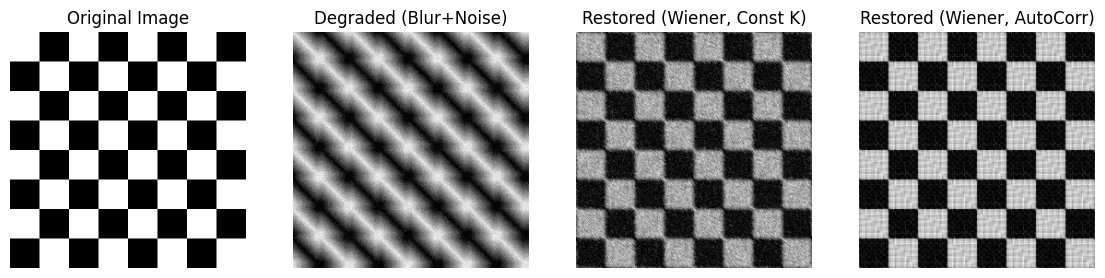

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Load grayscale image ===
img = cv2.imread("/content/drive/MyDrive/test256.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))

# === Step 2: Simulate degradation (motion blur + noise) ===
def motion_blur_psf(shape, a=0.1, b=0.1, T=1):
    """Motion blur Point Spread Function (PSF)"""
    M, N = shape
    U, V = np.meshgrid(np.arange(-N//2, N//2), np.arange(-M//2, M//2))
    H = T * (np.sinc(a*U + b*V) + 1e-8) * np.exp(-1j*np.pi*(a*U + b*V))
    return np.fft.ifftshift(H)

# PSF
H = motion_blur_psf(img.shape)

# Fourier transform of original
F = np.fft.fft2(img)

# Degraded in frequency domain
G = H * F

# Add Gaussian noise
noise = np.random.normal(0, 10, img.shape)
G_noisy = G + np.fft.fft2(noise)

# Degraded image
g = np.abs(np.fft.ifft2(G_noisy))

# === Step 3: (A) Wiener Filtering with Constant Ratio K ===
K = 0.01  # noise-to-signal ratio
W_filter_A = (np.conj(H)) / (np.abs(H)**2 + K)
F_hat_A = W_filter_A * G_noisy
f_hat_A = np.abs(np.fft.ifft2(F_hat_A))

# === Step 4: (B) Wiener Filtering using Autocorrelation ===
# Estimate power spectra
S_xx = np.abs(F)**2   # power spectrum of signal
S_nn = np.abs(np.fft.fft2(noise))**2  # power spectrum of noise
W_filter_B = (np.conj(H) * S_xx) / (np.abs(H)**2 * S_xx + S_nn + 1e-8)
F_hat_B = W_filter_B * G_noisy
f_hat_B = np.abs(np.fft.ifft2(F_hat_B))

# === Step 5: Display results ===
plt.figure(figsize=(14,6))

plt.subplot(1,4,1), plt.imshow(img, cmap='gray')
plt.title("Original Image"), plt.axis('off')

plt.subplot(1,4,2), plt.imshow(g, cmap='gray')
plt.title("Degraded (Blur+Noise)"), plt.axis('off')

plt.subplot(1,4,3), plt.imshow(f_hat_A, cmap='gray')
plt.title("Restored (Wiener, Const K)"), plt.axis('off')

plt.subplot(1,4,4), plt.imshow(f_hat_B, cmap='gray')
plt.title("Restored (Wiener, AutoCorr)"), plt.axis('off')

plt.show()


Q3

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Load RGB image ===
img = cv2.imread("/content/drive/MyDrive/image.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Normalize RGB values [0,1]
img_norm = img / 255.0
R = img_norm[:, :, 0]
G = img_norm[:, :, 1]
B = img_norm[:, :, 2]

# === Step 2: Compute H, S, I ===
# Intensity
I = (R + G + B) / 3

# Saturation
min_rgb = np.minimum(np.minimum(R, G), B)
S = 1 - (3 / (R + G + B + 1e-8)) * min_rgb

# Hue calculation
num = 0.5 * ((R - G) + (R - B))
den = np.sqrt((R - G)**2 + (R - B)*(G - B)) + 1e-8
theta = np.arccos(num / den)

H = np.zeros_like(R)

# If B <= G
H[B <= G] = theta[B <= G]
# If B > G
H[B > G] = 2*np.pi - theta[B > G]

# Normalize H to [0,1] for display
H = H / (2*np.pi)

# === Step 3: Display results ===
plt.figure(figsize=(12,6))

plt.subplot(1,4,1), plt.imshow(img)
plt.title("Original RGB"), plt.axis("off")

plt.subplot(1,4,2), plt.imshow(H, cmap='hsv')
plt.title("Hue Component"), plt.axis("off")

plt.subplot(1,4,3), plt.imshow(S, cmap='gray')
plt.title("Saturation Component"), plt.axis("off")

plt.subplot(1,4,4), plt.imshow(I, cmap='gray')
plt.title("Intensity Component"), plt.axis("off")

plt.show()


Q4

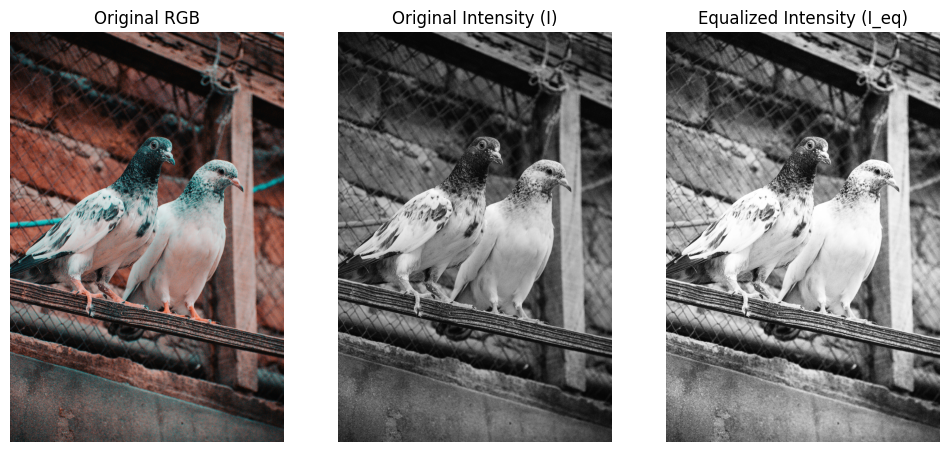

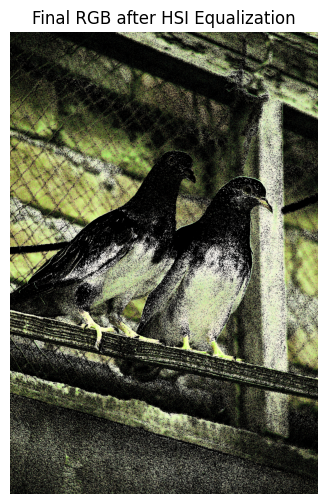

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 1. Load RGB Image
# ================================
img = cv2.imread("/content/drive/MyDrive/muhammad-murtaza-ghani-CIVbJZR8aAk-unsplash.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_norm = img / 255.0

R = img_norm[:, :, 0]
G = img_norm[:, :, 1]
B = img_norm[:, :, 2]

# ================================
# 2. Convert RGB → HSI
# ================================
# --- Intensity ---
I = (R + G + B) / 3

# --- Saturation ---
min_rgb = np.minimum(np.minimum(R, G), B)
S = 1 - (3 / (R + G + B + 1e-8)) * min_rgb

# --- Hue ---
num = 0.5 * ((R - G) + (R - B))
den = np.sqrt((R - G)**2 + (R - B)*(G - B)) + 1e-8
theta = np.arccos(num / den)

H = np.zeros_like(R)
H[B <= G] = theta[B <= G]
H[B > G] = 2*np.pi - theta[B > G]

# ================================
# 3. Histogram Equalization of I
# ================================
I_uint8 = (I * 255).astype(np.uint8)
I_eq = cv2.equalizeHist(I_uint8)
I_eq = I_eq / 255.0    # back to [0,1]

# ================================
# 4. Recombine H, S, I_eq to new HSI
# ================================
H_new = H
S_new = S
I_new = I_eq

# ================================
# 5. Convert HSI → RGB
# ================================
H_deg = H_new * 360
R_new = np.zeros_like(H_new)
G_new = np.zeros_like(H_new)
B_new = np.zeros_like(H_new)

# Sector 1: 0–120 degrees
idx = (H_deg >= 0) & (H_deg < 120)
B_new[idx] = I_new[idx] * (1 - S_new[idx])
R_new[idx] = I_new[idx] * (1 + (S_new[idx] * np.cos(np.deg2rad(H_deg[idx]))) /
                           (np.cos(np.deg2rad(60 - H_deg[idx])) + 1e-8))
G_new[idx] = 3 * I_new[idx] - (R_new[idx] + B_new[idx])

# Sector 2: 120–240 degrees
idx = (H_deg >= 120) & (H_deg < 240)
H2 = H_deg - 120
R_new[idx] = I_new[idx] * (1 - S_new[idx])
G_new[idx] = I_new[idx] * (1 + (S_new[idx] * np.cos(np.deg2rad(H2[idx]))) /
                           (np.cos(np.deg2rad(60 - H2[idx])) + 1e-8))
B_new[idx] = 3 * I_new[idx] - (R_new[idx] + G_new[idx])

# Sector 3: 240–360 degrees
idx = (H_deg >= 240) & (H_deg < 360)
H3 = H_deg - 240
G_new[idx] = I_new[idx] * (1 - S_new[idx])
B_new[idx] = I_new[idx] * (1 + (S_new[idx] * np.cos(np.deg2rad(H3[idx]))) /
                           (np.cos(np.deg2rad(60 - H3[idx])) + 1e-8))
R_new[idx] = 3 * I_new[idx] - (G_new[idx] + B_new[idx])

# Clip to valid range
RGB_new = np.stack([R_new, G_new, B_new], axis=2)
RGB_new = np.clip(RGB_new, 0, 1)

# Convert to display format
RGB_new_uint8 = (RGB_new * 255).astype(np.uint8)

# ================================
# 6. Display Results
# ================================
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(I, cmap='gray')
plt.title("Original Intensity (I)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(I_eq, cmap='gray')
plt.title("Equalized Intensity (I_eq)")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.imshow(RGB_new_uint8)
plt.title("Final RGB after HSI Equalization")
plt.axis("off")

plt.show()


Q5

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 1. Load Binary Image
# ================================
# Use your own binary image here
img = cv2.imread("/content/drive/MyDrive/binaryyyyy.png", 0)

# If not binary, convert it:
_, binary = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)

# Invert if needed (Hough works better with white lines)
binary = 255 - binary

# ================================
# 2. Detect edges for Hough Transform
# ================================
edges = cv2.Canny(binary, 50, 150, apertureSize=3)

# ================================
# 3. Probabilistic Hough Transform
# ================================
lines = cv2.HoughLinesP(edges,
                        rho=1,
                        theta=np.pi/180,
                        threshold=50,
                        minLineLength=20,
                        maxLineGap=10)

# Create color image for visualization
output = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)

# Draw detected line segments
if lines is not None:
    for (x1, y1, x2, y2) in lines[:, 0]:
        cv2.line(output, (x1, y1), (x2, y2), (255, 0, 0), 2)

# ================================
# 4. Display results
# ================================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Edges (Canny)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(output)
plt.title("Detected Line Segments")
plt.axis("off")

plt.show()


Q6

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read the image (grayscale)
# -----------------------------
img = cv2.imread("/content/drive/MyDrive/image.png", cv2.IMREAD_GRAYSCALE)

# -----------------------------
# 2. Apply thresholding
#    OTSU automatically finds best threshold
# -----------------------------
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# -----------------------------
# 3. Remove noise (optional)
# -----------------------------
kernel = np.ones((3, 3), np.uint8)
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

# -----------------------------
# 4. Label the blobs
# -----------------------------
num_labels, labels = cv2.connectedComponents(clean)

print("Number of blobs detected:", num_labels - 1)  # subtract background

# -----------------------------
# 5. Display results
# -----------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Thresholded Image")
plt.imshow(clean, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Segmented Blobs")
plt.imshow(labels, cmap="nipy_spectral")
plt.axis("off")

plt.show()


Q7

Number of blobs detected: 3707


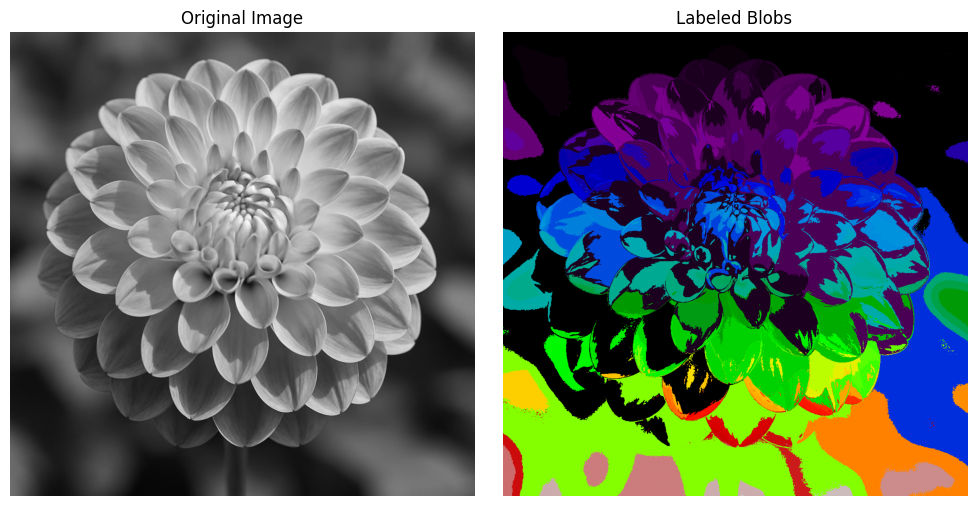

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# -----------------------------
# 1. Read grayscale image
# -----------------------------
img = cv2.imread("/content/drive/MyDrive/grayscale_image.jpg", cv2.IMREAD_GRAYSCALE)

# Normalize to 0–1
image = img.astype(np.float32) / 255.0

# -----------------------------
# 2. Parameters
# -----------------------------
threshold = 0.08        # intensity similarity
visited = np.zeros_like(image, dtype=bool)
labels = np.zeros_like(image, dtype=np.int32)
label_id = 1

# 8-neighbour directions
neighbors = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(1,1),(1,-1),( -1, 1)]

# -----------------------------
# 3. Region Growing Algorithm
# -----------------------------
def region_grow(seed_x, seed_y, label):
    q = deque()
    q.append((seed_x, seed_y))

    visited[seed_x, seed_y] = True
    labels[seed_x, seed_y] = label
    seed_value = image[seed_x, seed_y]

    while q:
        x, y = q.popleft()

        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy

            if 0 <= nx < image.shape[0] and 0 <= ny < image.shape[1]:
                if not visited[nx, ny]:
                    if abs(image[nx, ny] - seed_value) < threshold:
                        visited[nx, ny] = True
                        labels[nx, ny] = label
                        q.append((nx, ny))


# -----------------------------
# 4. Automatically pick seeds
# -----------------------------
for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        if not visited[i, j]:
            # Start a new region
            region_grow(i, j, label_id)
            label_id += 1

print("Number of blobs detected:", label_id - 1)

# -----------------------------
# 5. Display results
# -----------------------------
plt.figure(figsize=(10,5)) # Adjusted figsize for 2 subplots

plt.subplot(1,2,1) # Changed to 1,2,1
plt.title("Original Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2) # Changed to 1,2,2
plt.title("Labeled Blobs")
plt.imshow(labels, cmap="nipy_spectral")
plt.axis("off")

plt.tight_layout()
plt.show()

Q8

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Utility: check if region should be split (variance test)
# ---------------------------------------------------------
def should_split(region, threshold):
    return np.var(region) > threshold

# ---------------------------------------------------------
# Split phase (Quad-tree)
# ---------------------------------------------------------
def split(image, x, y, size, min_size, threshold, regions):
    region = image[x:x+size, y:y+size]

    # If size is smaller than min_size → stop splitting
    if size <= min_size or not should_split(region, threshold):
        regions.append((x, y, size))
        return

    half = size // 2
    # split into 4 quadrants
    split(image, x,       y,       half, min_size, threshold, regions)
    split(image, x,       y+half,  half, min_size, threshold, regions)
    split(image, x+half,  y,       half, min_size, threshold, regions)
    split(image, x+half,  y+half,  half, min_size, threshold, regions)

# ---------------------------------------------------------
# Merge phase: merge adjacent regions with similar mean
# ---------------------------------------------------------
def merge(image, regions, merge_threshold):
    label_map = -1 * np.ones(image.shape, dtype=np.int32)
    label = 0
    region_means = []

    for (x, y, size) in regions:
        region = image[x:x+size, y:y+size]
        mean_val = np.mean(region)
        region_means.append(mean_val)

        # assign label
        label_map[x:x+size, y:y+size] = label
        label += 1

    # merge: if difference between region means is small
    merged = label_map.copy()
    for i in range(label_map.shape[0]-1):
        for j in range(label_map.shape[1]-1):
            current = label_map[i, j]
            right   = label_map[i, j+1]
            down    = label_map[i+1, j]

            if current != right:
                if abs(region_means[current] - region_means[right]) < merge_threshold:
                    merged[merged == right] = current

            if current != down:
                if abs(region_means[current] - region_means[down]) < merge_threshold:
                    merged[merged == down] = current

    return merged


# ---------------------------------------------------------
# Driver function
# ---------------------------------------------------------
def split_merge_segmentation(image_path, min_size, split_threshold=0.01, merge_threshold=0.02):
    img = cv2.imread(image_path, 0) / 255.0  # grayscale + normalize

    N = img.shape[0]

    # ensure power of 2
    size = 1 << (N - 1).bit_length()
    padded = np.zeros((size, size))
    padded[:N, :N] = img

    regions = []
    split(padded, 0, 0, size, min_size, split_threshold, regions)

    merged_map = merge(padded, regions, merge_threshold)

    # crop back to original size
    merged_map = merged_map[:N, :N]

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title(f"Split & Merge (min_size={min_size})")
    plt.imshow(merged_map, cmap="gray")
    plt.axis("off")

    plt.show()

    return merged_map

In [ ]:
split_merge_segmentation("/content/drive/MyDrive/grayscale_image.jpg", min_size=8)
split_merge_segmentation("/content/drive/MyDrive/grayscale_image.jpg", min_size=16)
split_merge_segmentation("/content/drive/MyDrive/grayscale_image.jpg", min_size=32)


Q9

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def watershed_blob_segmentation(image_path):

    # Step 1: Read image
    img = cv2.imread(image_path, 0)

    # Ensure binary format
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Invert (watershed works on white foreground)
    binary_inv = cv2.bitwise_not(binary)

    # Step 2: Distance transform
    dist = cv2.distanceTransform(binary_inv, cv2.DIST_L2, 5)

    # Normalize for visualization
    dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)

    # Step 3: Threshold distance map to get sure foreground
    _, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    # Step 4: Sure background (dilation)
    kernel = np.ones((3, 3), np.uint8)
    sure_bg = cv2.dilate(binary_inv, kernel, iterations=2)

    # Step 5: Unknown region
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Step 6: Marker labeling
    num_markers, markers = cv2.connectedComponents(sure_fg)

    # Increment markers so background = 1 instead of 0
    markers = markers + 1

    # Mark unknown as 0
    markers[unknown == 255] = 0

    # Convert to 3-channel image
    img_color = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

    # Step 7: Apply watershed
    markers = cv2.watershed(img_color, markers)

    # Random color map for segments
    output = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
    for m in range(2, num_markers + 1):
        output[markers == m] = np.random.randint(0, 255, 3)

    # Plot results
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Binary Image")
    plt.imshow(binary, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Distance Transform")
    plt.imshow(dist_norm, cmap="jet")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Watershed Segmented Blobs")
    plt.imshow(output)
    plt.axis("off")

    plt.show()

    #return output





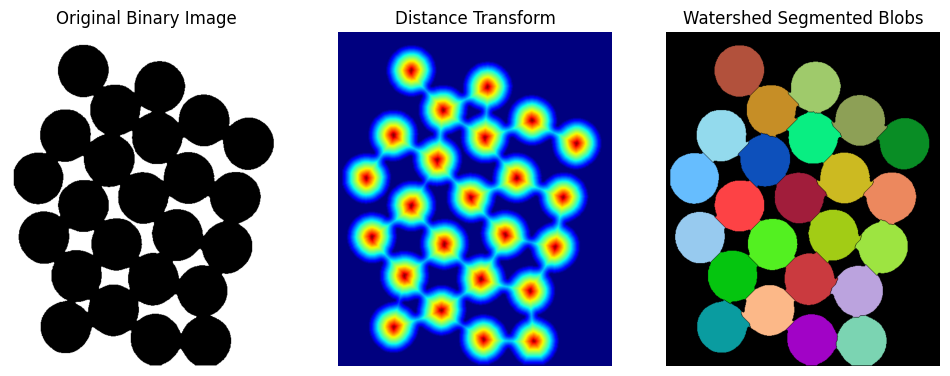

In [2]:
watershed_blob_segmentation("/content/drive/MyDrive/coins.png")